In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

# Automatically locate your active Miniconda environment's plugin directory
conda_prefix = os.environ.get("CONDA_PREFIX")
if conda_prefix:
    # On Windows, Conda puts plugin DLLs in Library\bin\gdalplugins
    plugin_path = os.path.join(conda_prefix, "Library", "lib", "gdalplugins")
    os.environ["GDAL_DRIVER_PATH"] = plugin_path
    # Append the main bin directory to the system PATH so dependencies load
    os.environ["PATH"] = os.path.join(conda_prefix, "Library", "lib") + os.pathsep + os.environ["PATH"]

from nbs_uncles import (
    read_file, show_depth,
    build_coverage_mask,
    compute_dominant_angle_radon_transform, compute_local_orientation,
    undo_rotation,
    compute_uncertainty,
    detect_trackline_positions, assign_depths_to_lines,
    build_uncertainty_raster,
)

# scikit-image functions used directly in notebook cells
from skimage.morphology import opening, thin, disk

import numpy as np
import matplotlib.pyplot as plt

## Trackline Detection via combined Radon Transform and Local Angle Detection

This notebook detects and extracts individual **survey tracklines** from a bathymetric raster by exploiting the linear spatial structure left by vessel survey passes.

**Overall pipeline:**

1. Load the BAG raster 
2. Build a binary coverage mask.
3. Apply morphological filtering to suppress blob-like dense coverage patches, leaving only thin linear trackline structures.
4. Skeletonise the filtered image to single-pixel-width lines.
5. Use the **Radon transform** to identify the dominant line orientations (angle peaks).
6. Compute local angle orientation of points using PCA
6. Iteratively extract line families: for each dominant angle, rotate the original bathymetry to align it to the vertical axis and sample the points that intersect with the vertical lines defined by the angle peaks 
7. For each extracted family, assign real depth values based on original data
8. With each extracted family now consisting of parallel lines, we can process pairs of lines iteratively

For each pair of lines:

9. Interpolated bathymetry values of there are gaps within the lines
10. Compute the uncertainty for each line in the pair using the spectral energy using distance between the pair of lines as "linespacing"
11. Divide each line into subsegments with lengths equal to linespacing and apply spectral energy computation on each subsegment resulting to 2D array of spectral energies
12. Place the computed 2D arrays to the space between the line pairs

After processing all line pairs:

13. Rotate the resulting raster back to its original orientation (negative of dominant angle)
14. Plot the resulting raster

1. Load the BAG raster

Load the BAG (Bathymetric Attributed Grid) raster file. The result is a dict containing the raw 2D depth array and metadata (geotransform, resolution, no-data value). No-data values are **not** masked on load — they are handled explicitly in subsequent steps.

File '../data/raster/D00141_VB_4m_MLLW_1of1.bag' read successfully.
Data shape: 11816 rows x 8364 columns
No-data value: 1000000.0
Resolution: 4.0 m/pixel
Geotransform values--> 
Origin x-coordinate: 261730.28
Pixel width: 4.0
Row rotation: 0.0
Origin y-coordinate: 3300579.9
Column rotation: 0.0
Pixel height: -4.0



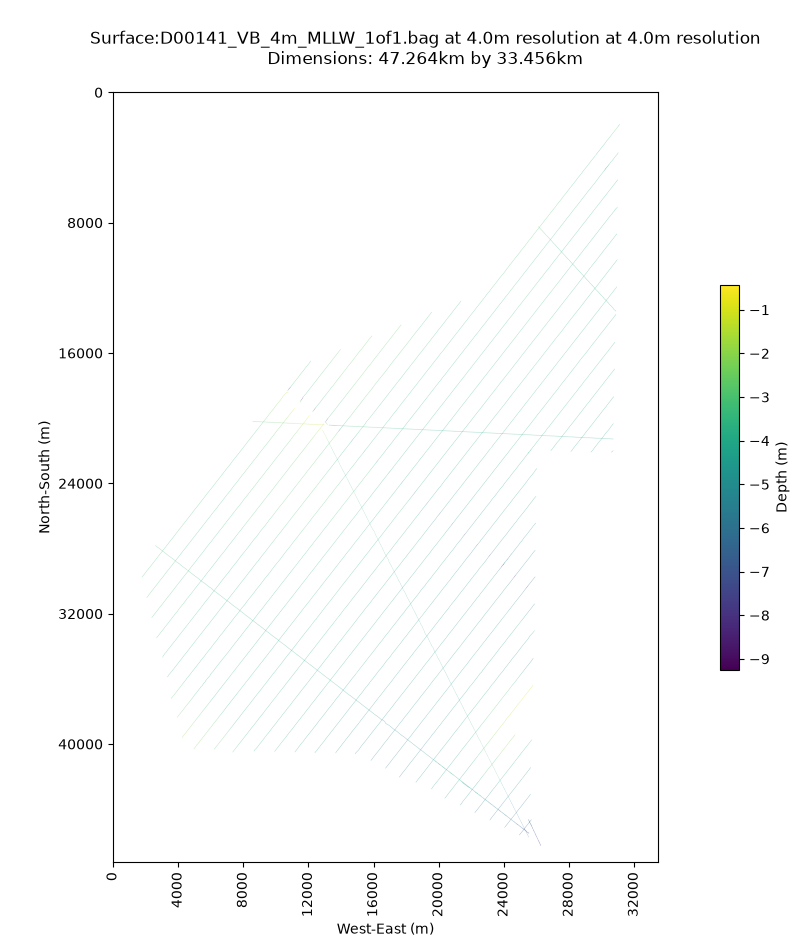

In [3]:
fn = r"../data/raster/D00141_VB_4m_MLLW_1of1.bag"
bathy_data = read_file(fn, verbose=True)

# Visualize the loaded bathymetric data
show_depth(bathy_data, cmap='viridis')

2. Build a binary coverage mask

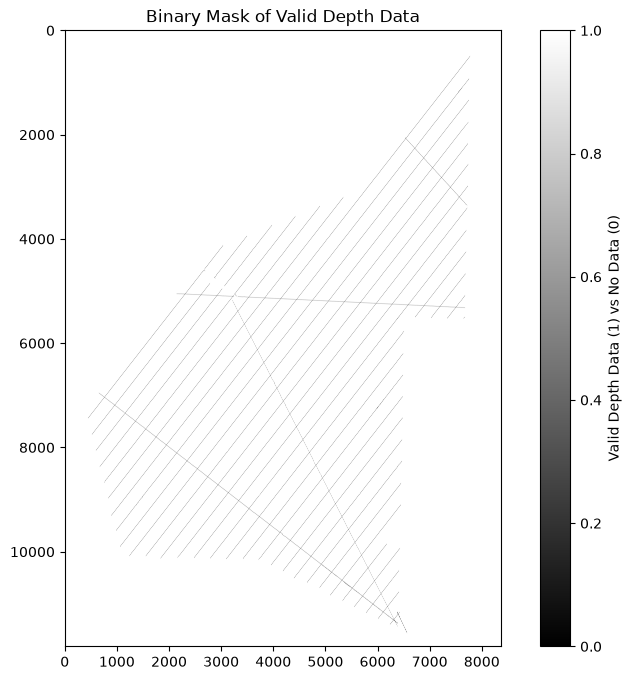

In [4]:
bathy_binary = build_coverage_mask(bathy_data)

plt.figure(figsize=(10, 8))
plt.imshow(1 - bathy_binary, cmap='gray')
plt.colorbar(label='Valid Depth Data (1) vs No Data (0)')
plt.title("Binary Mask of Valid Depth Data")
plt.show()

3. Apply morphological filtering to suppress blob-like patches
4. Skeletonise the filtered image to single-pixel-width lines

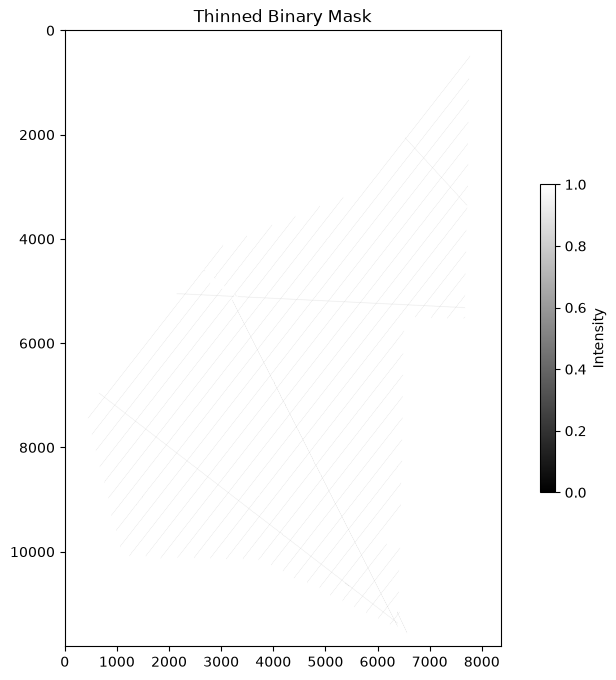

In [5]:
# Apply morphological thinning to the binary mask
# Remove blob-like structures while preserving the skeleton of valid data
bathy_blobs = opening(bathy_binary, disk(5))  # Remove small blobs
bathy_lines = bathy_binary & ~bathy_blobs  # Keep only the line-like structures
bathy_thin = thin(bathy_lines) > 0
plt.figure(figsize=(10, 8))
plt.imshow(1 - bathy_thin, cmap='gray')
plt.title("Thinned Binary Mask")
plt.colorbar(label='Intensity', shrink=0.5)
plt.show()


5. Use the **Radon transform** to identify the dominant line orientations (angles).

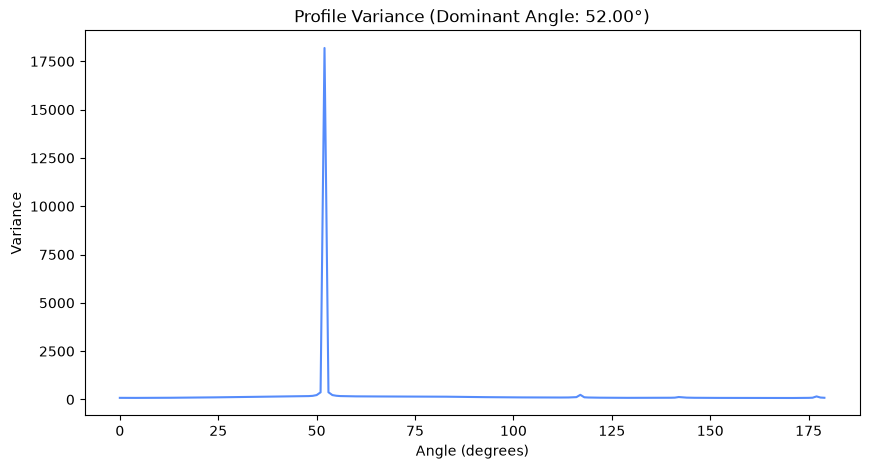

In [6]:
# Run the Radon transform over the full skeleton to identify the single most
# prominent orientation. The variance profile peaks at angles where projections
# are concentrated — characteristic of linear features aligned with that angle.
dominant_orientations = compute_dominant_angle_radon_transform(
    bathy_thin, plot_profile_variance=True, circle=False
)


In [7]:
print(f"Dominant Orientations: {dominant_orientations['peaks']}")

Dominant Orientations: [ 52 117 177 142 132]


6. Compute local angle orientation of points using PCA

100%|██████████| 149407/149407 [01:37<00:00, 1537.92it/s]


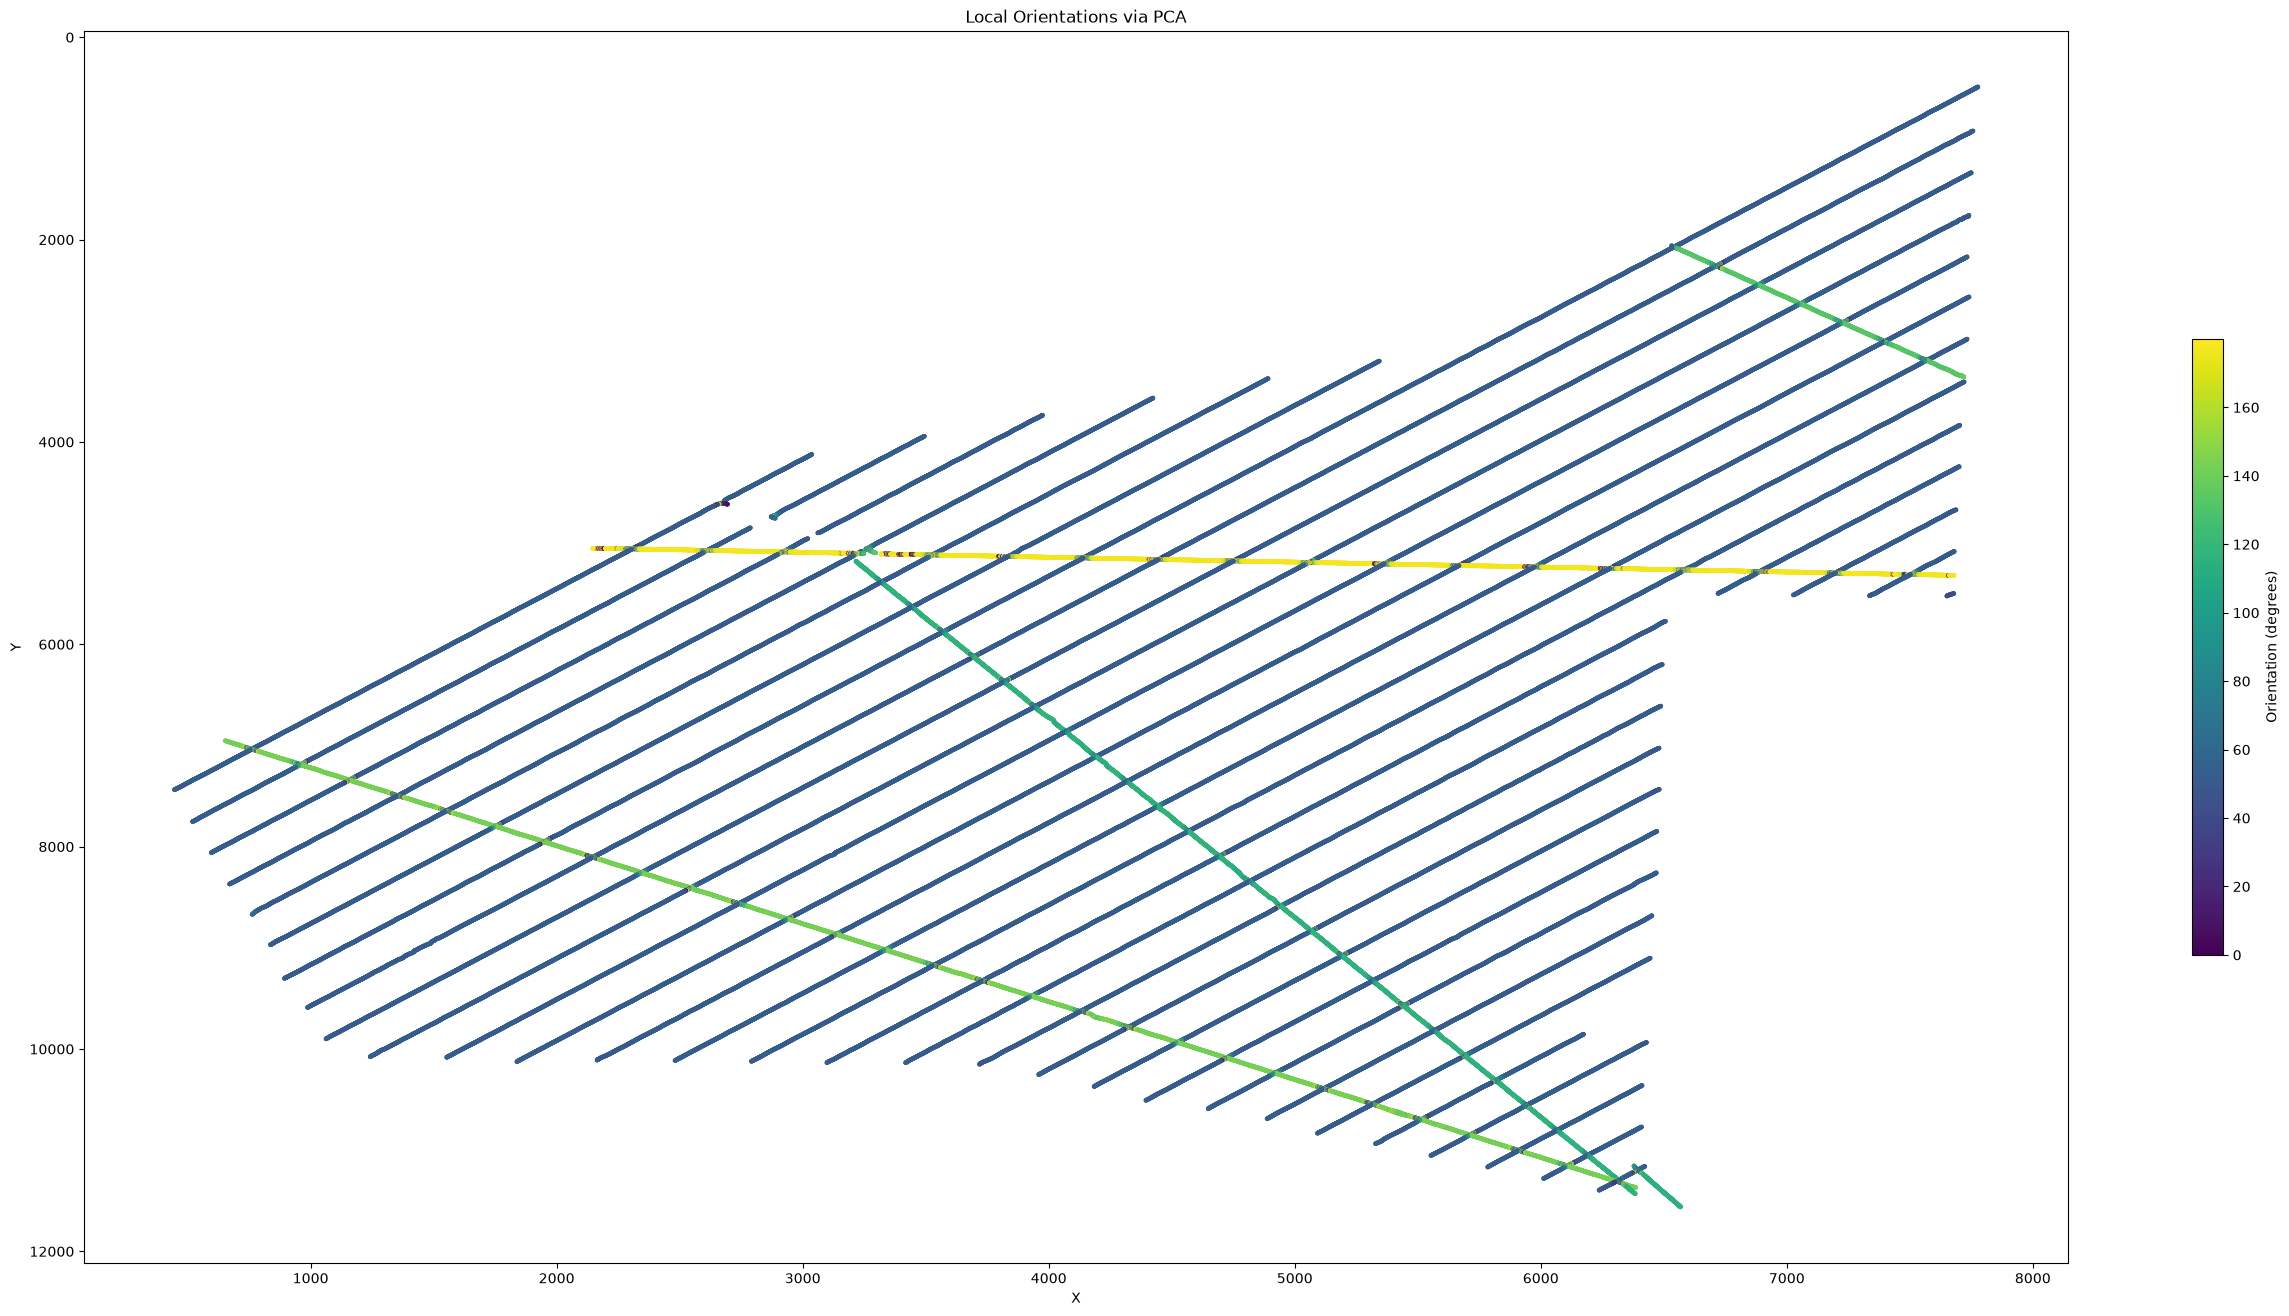

In [8]:
local_orientations = compute_local_orientation(
    binary_image=bathy_thin,
    line_length=50,
    num_neighbors=20,
    plot_orientation=True,
    cmap = 'viridis',
    figsize=(32, 16)
)

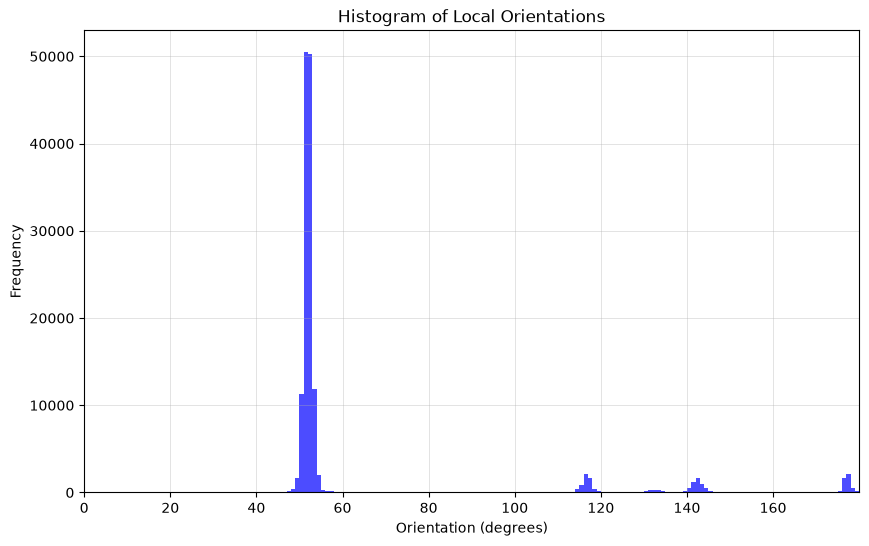

In [9]:
# Compute histogram of local orientations
plt.figure(figsize=(10, 6))
min_angle = np.nanmin(local_orientations)
max_angle = np.nanmax(local_orientations)
plt.hist(local_orientations[~np.isnan(local_orientations)].flatten(), bins=180, range=(min_angle, max_angle), color='blue', alpha=0.7)
plt.title("Histogram of Local Orientations")
plt.xlabel("Orientation (degrees)")
plt.ylabel("Frequency")
plt.xlim(min_angle, max_angle)
plt.grid(True)
plt.show()

6. Iteratively extract line families: for each dominant angle, rotate the original bathymetry to align it to the vertical axis and sample the points that intersect with the vertical lines defined by the angle peaks

In [10]:
TARGET_ANGLES = dominant_orientations['peaks']

# Override detected TARGET_ANGLES as necessary
TARGET_ANGLES = [52]

Using min_line_length = 236 pixels (2.0% of max dimension)
Extracting lines around 52° ± 5°
  Angle range: 47.0° to 57.0°


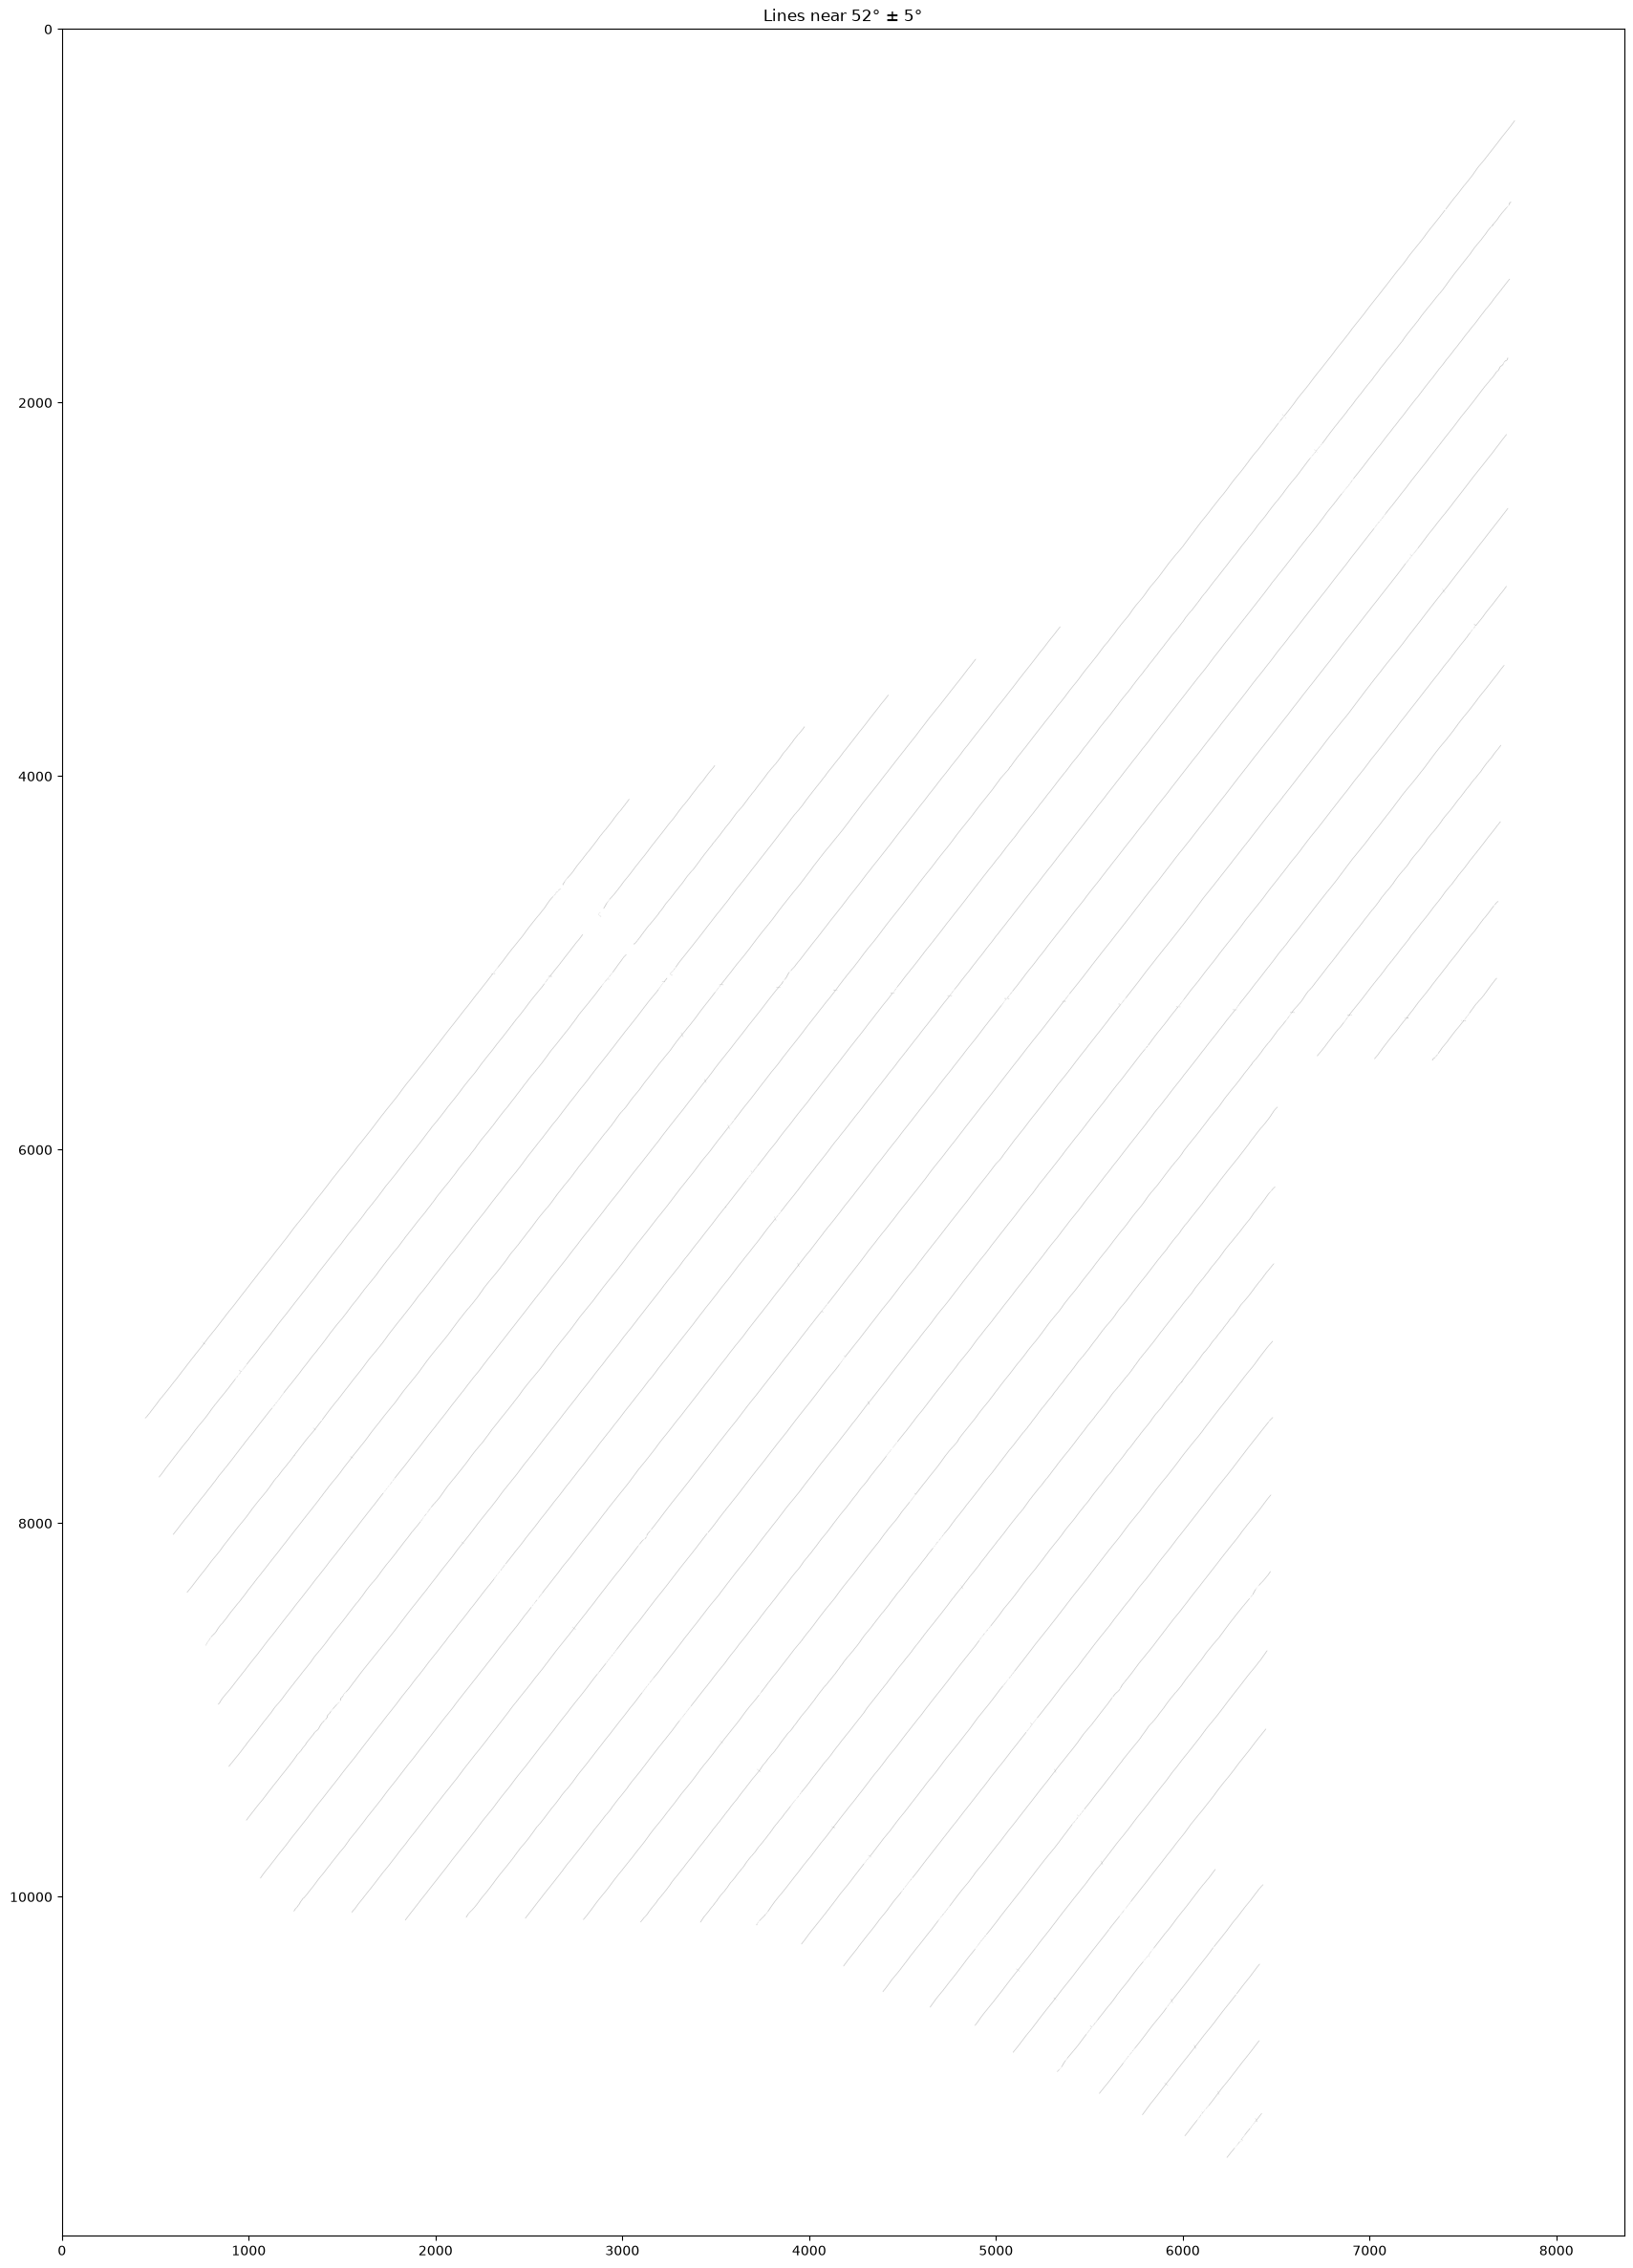

In [11]:
# Use 10% of longest dimension as the minimum line length
# this is a heuristic that captures the scale of features we expect to see
# Adjust as needed for different datasets.
min_line_pct = 0.02
min_line_length = int(min_line_pct * max(bathy_thin.shape))
print(f"Using min_line_length = {min_line_length} pixels "
      f"({min_line_pct*100:.1f}% of max dimension)")

if len(TARGET_ANGLES) > 1:
    angle_search_window = int(np.floor(np.min(np.diff(TARGET_ANGLES))) - 1) // 2
    TOLERANCE = angle_search_window # degrees of tolerance around each target angle
    TOLERANCE = min(TOLERANCE, 5)  # Ensure at least 5 degrees of tolerance
else:
    TOLERANCE = 5

angle_colors = plt.cm.viridis(np.linspace(0, 1, len(TARGET_ANGLES)))

angles_rasters = {}

for i, angle in enumerate(TARGET_ANGLES):
    print(f"Extracting lines around {angle}° ± {TOLERANCE}°")
    # Extract lines near this angle
    low_bound = (angle - TOLERANCE) % 180
    high_bound = (angle + TOLERANCE) % 180
    print(f"  Angle range: {low_bound:.1f}° to {high_bound:.1f}°")
    # Create a mask of pixels whose local orientation falls within this range
    if low_bound < high_bound:
        range_condition = np.logical_and(local_orientations >= low_bound, 
                                         local_orientations < high_bound,
                                         ~np.isnan(local_orientations))
    else:
        range_condition = np.logical_or(local_orientations >= low_bound, 
                                        local_orientations < high_bound,
                                        ~np.isnan(local_orientations))
        
    angles_rasters[angle] = range_condition
    
    plt.figure(figsize=(30, 30))
    plt.imshow(1 - range_condition.astype(bool), cmap='gray')
    plt.title(f"Lines near {angle}° ± {TOLERANCE}°")
    plt.show()

    

7. For each extracted family, assign real depth values based on original data
8. With each extracted family now consisting of parallel lines, we can process pairs of lines iteratively

For each pair of lines:

9. Interpolated bathymetry values of there are gaps within the lines
10. Compute the uncertainty for each line in the pair using the spectral energy using distance between the pair of lines as "linespacing"
11. Divide each line into subsegments with lengths equal to linespacing and apply spectral energy computation on each subsegment resulting to 2D array of spectral energies
12. Place the computed 2D arrays to the space between the line pairs

After processing all line pairs:

13. Rotate the resulting raster back to its original orientation (negative of dominant angle)
14. Plot the resulting raster

Angle 52°: detected 25 tracklines at columns [ 4932  5181  5432  5681  5931  6181  6431  6681  6931  7181  7431  7681
  7931  8181  8431  8681  8931  9181  9431  9681  9932 10181 10431 10682
 11182]


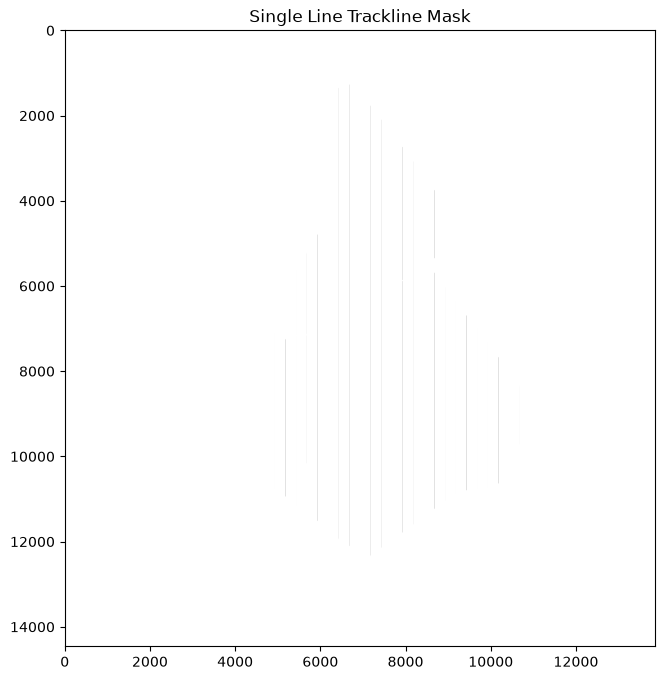

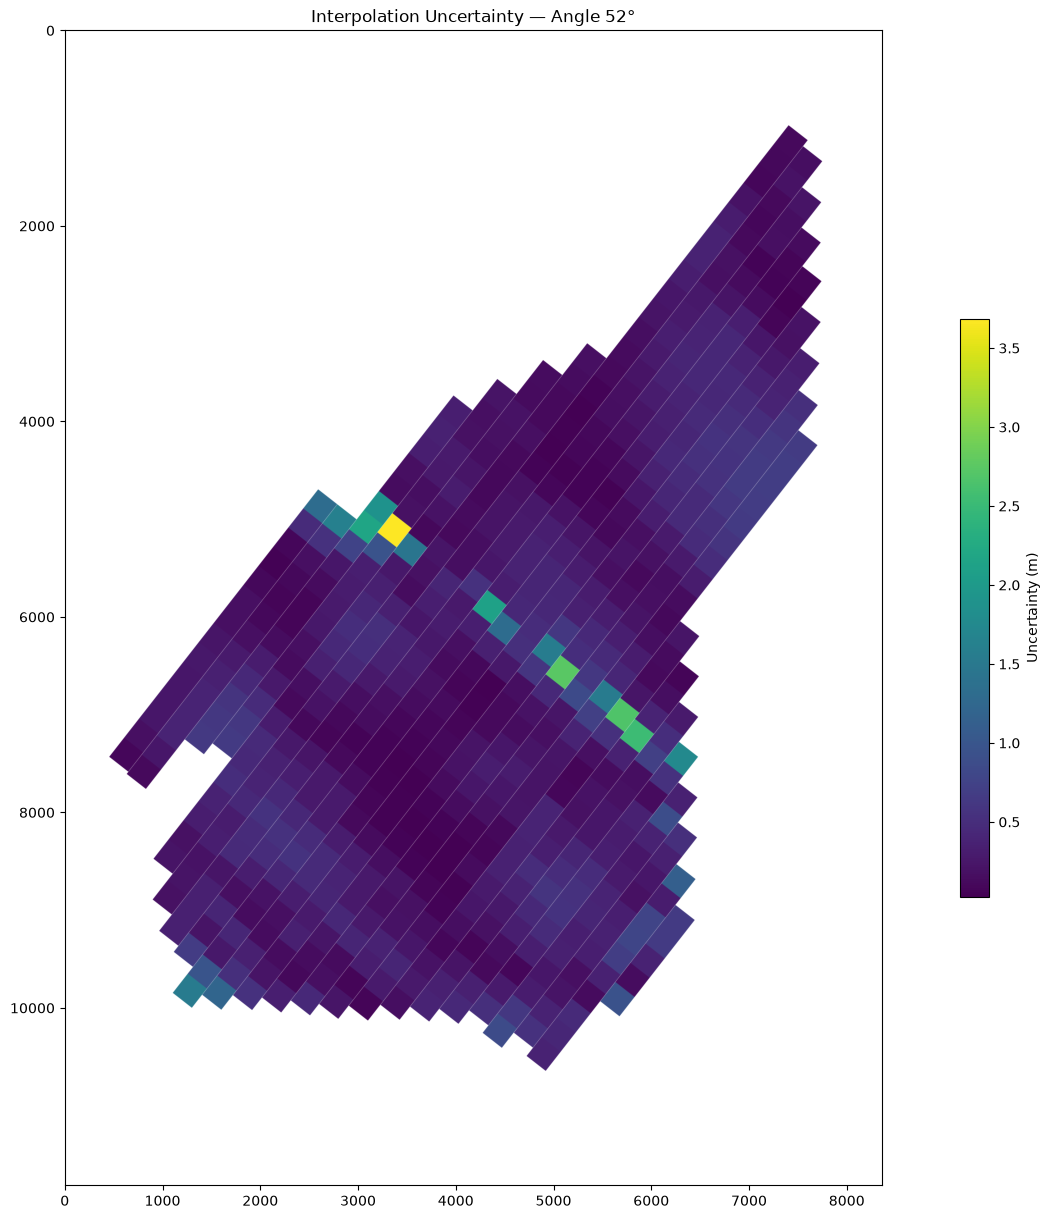

In [15]:
min_line_factor = 0.1  # fraction of max projection height used as the peak threshold
band_width      = 40   # minimum column separation between adjacent detected peaks (pixels)

uncertainty_results = {}  # keyed by angle — stores the final uncertainty raster per family

for angle in TARGET_ANGLES:
    current_mask = angles_rasters[angle]

    # --- Steps 7–8: Detect trackline positions and build the clean line mask ---
    peaks, restored_mask, angle_to_rotate = detect_trackline_positions(
        angle_mask=current_mask,
        bathy_binary=bathy_binary,
        angle=angle,
        min_line_factor=min_line_factor,
        band_width=band_width,
    )
    print(f"Angle {angle}°: detected {len(peaks)} tracklines at columns {peaks}")

        # Plot restored mask
    plt.figure(figsize=(10, 8))
    plt.imshow(1 - restored_mask, cmap='gray')
    plt.title("Single Line Trackline Mask")

    # Assign real depth values from bathy_data to each detected line pixel
    current_depth_raster = assign_depths_to_lines(
        restored_mask=restored_mask,
        bathy_binary=bathy_binary,
        bathy_data=bathy_data,
        angle_to_rotate=angle_to_rotate,
    )

    # --- Steps 9–12: Process all adjacent line pairs → uncertainty raster ---
    uncertainty_raster = build_uncertainty_raster(
        peaks=peaks,
        restored_mask=restored_mask,
        current_depth_raster=current_depth_raster,
        resolution=bathy_data['metadata']['resolution'],
    )

    # --- Step 13: Rotate uncertainty raster back to original orientation ---
    uncertainty_original = undo_rotation(
        raster=uncertainty_raster,
        angle_to_rotate=angle_to_rotate,
        original_shape=current_mask.shape,
    )

    uncertainty_results[angle] = uncertainty_original

    # --- Step 14: Plot ---
    plt.figure(figsize=(20, 15))
    plt.imshow(uncertainty_original, cmap='viridis')
    plt.colorbar(label='Uncertainty (m)', shrink=0.5)
    plt.title(f'Interpolation Uncertainty — Angle {angle}°')
    plt.show()


In [13]:
## ── Method comparison ────────────────────────────────────────────────────────
# Run the pipeline for every spectral method in compute_uncertainty and display
# the resulting uncertainty rasters side-by-side so the effect of each method
# on the uncertainty estimate can be assessed visually.
#
# Strategy:
#   - detect_trackline_positions + assign_depths_to_lines are method-independent
#     (pure geometry + depth lookup), so we compute them ONCE per angle and cache.
#   - build_uncertainty_raster is then run for each method — fast because it
#     only redoes the FFT step.

METHODS = ['amplitude', 'psd', 'psd_n', 'psd_df']

# --- Step A: Cache geometry + depth for each angle (run once) ---
angle_cache = {}
for angle in TARGET_ANGLES:
    current_mask = angles_rasters[angle]
    peaks, restored_mask, angle_to_rotate = detect_trackline_positions(
        angle_mask=current_mask,
        bathy_binary=bathy_binary,
        angle=angle,
        min_line_factor=min_line_factor,
        band_width=band_width,
    )
    current_depth_raster = assign_depths_to_lines(
        restored_mask=restored_mask,
        bathy_binary=bathy_binary,
        bathy_data=bathy_data,
        angle_to_rotate=angle_to_rotate,
    )
    angle_cache[angle] = dict(
        current_mask=current_mask,
        peaks=peaks,
        restored_mask=restored_mask,
        angle_to_rotate=angle_to_rotate,
        current_depth_raster=current_depth_raster,
    )



Processing angle 52° with method 'amplitude' with ax Axes(0.125,0.712609;0.775x0.167391)...
Processing angle 52° with method 'psd' with ax Axes(0.125,0.511739;0.775x0.167391)...
Processing angle 52° with method 'psd_n' with ax Axes(0.125,0.31087;0.775x0.167391)...
Processing angle 52° with method 'psd_df' with ax Axes(0.125,0.11;0.775x0.167391)...


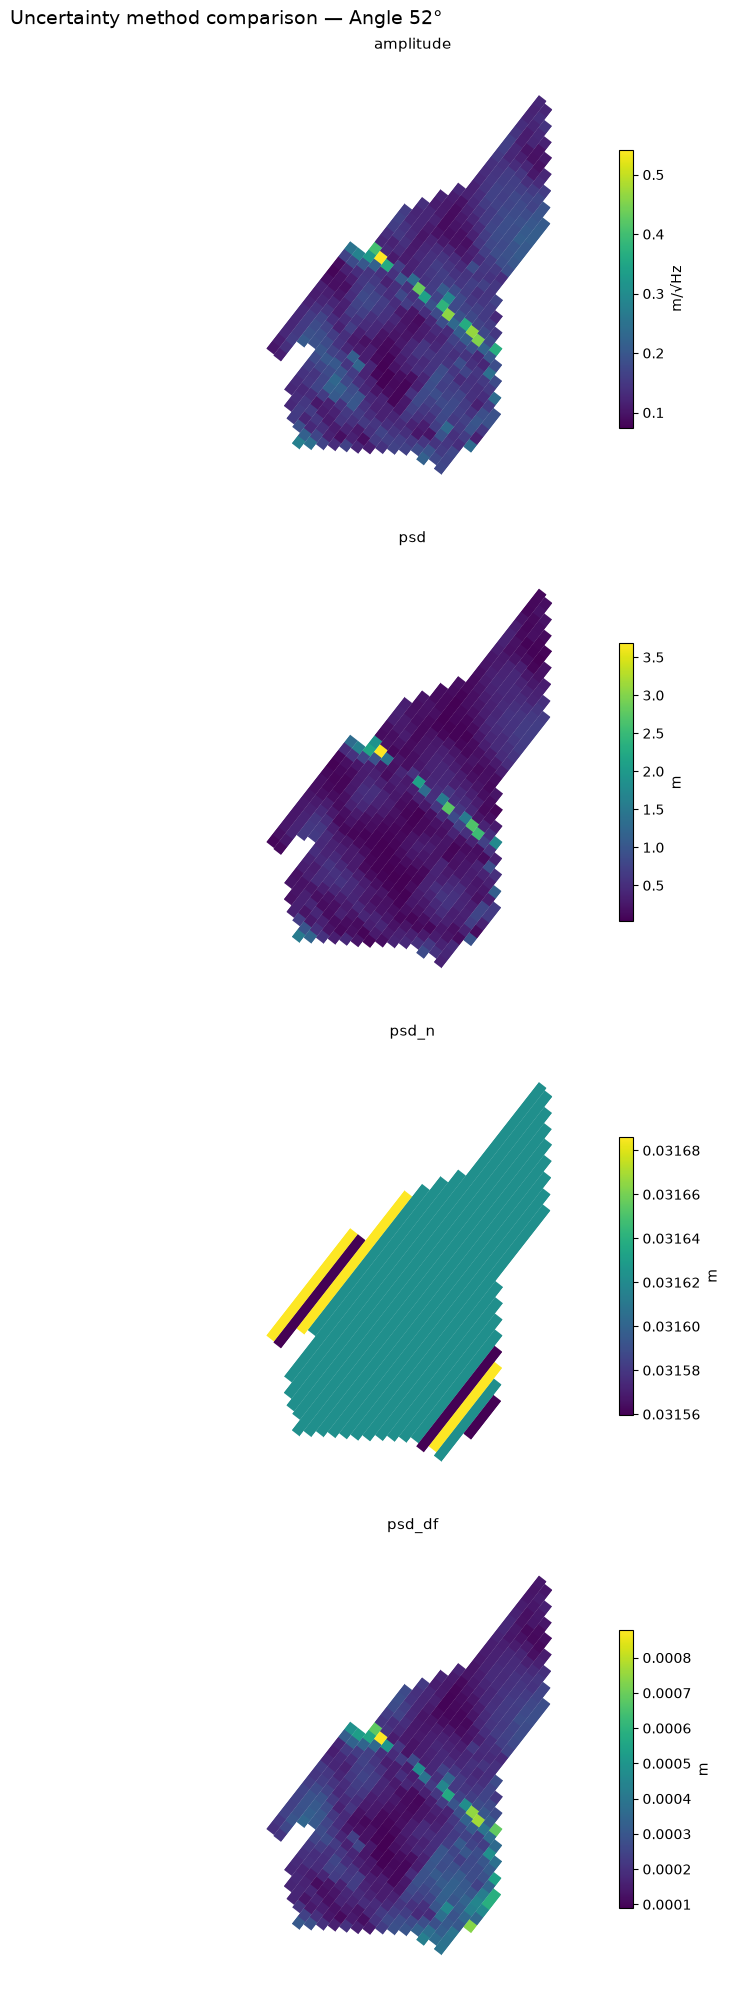

In [14]:
# --- Step B: Loop over methods and plot a row of subplots per angle ---
resolution = bathy_data['metadata']['resolution']

for angle, cache in angle_cache.items():
    n_methods = len(METHODS)
    fig, axes = plt.subplots(n_methods, 1, figsize=(10, 5 * n_methods),
                             constrained_layout=True)
    fig.suptitle(f'Uncertainty method comparison — Angle {angle}°', fontsize=14)
    for ax, method in zip(axes.flatten(), METHODS):
        print(f"Processing angle {angle}° with method '{method}' with ax {ax}...")
        uncertainty_raster = build_uncertainty_raster(
            peaks=cache['peaks'],
            restored_mask=cache['restored_mask'],
            current_depth_raster=cache['current_depth_raster'],
            resolution=resolution,
            method=method,
        )
        uncertainty_original = undo_rotation(
            raster=uncertainty_raster,
            angle_to_rotate=cache['angle_to_rotate'],
            original_shape=cache['current_mask'].shape,
        )
        im = ax.imshow(uncertainty_original, cmap='viridis')
        ax.set_title(method, fontsize=11)
        ax.axis('off')
        plt.colorbar(im, ax=ax, shrink=0.6,
                     label='m' if method != 'amplitude' else 'm/√Hz')

plt.show()